# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/boddulavinaykumar6-stack/Flyrank-ML-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [1]:
# Capstone research question

research_question = (
    "Can historical search and engagement signals rank content pages "
    "that are more likely to experience click improvement in the following month?"
)

decision_supported = (
    "Help an editor prioritize which content pages should be reviewed first "
    "for potential refresh or improvement."
)

unit_of_analysis = "client × content"

print("Research question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

print("\nUnit of analysis:")
print(unit_of_analysis)

Research question:
Can historical search and engagement signals rank content pages that are more likely to experience click improvement in the following month?

Decision supported:
Help an editor prioritize which content pages should be reviewed first for potential refresh or improvement.

Unit of analysis:
client × content


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [2]:
# Capstone — Data loading and dataset construction

import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata

# ---------------------------------------------------------
# 1. Connect to the FlyRank warehouse
# ---------------------------------------------------------

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(f"""
CREATE SECRET hf_secret (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
)
""")

rel = "hf://datasets/FlyRank/internship-warehouse"

print("Warehouse connection ready.")


# ---------------------------------------------------------
# 2. Load March 2026 — feature window
# ---------------------------------------------------------

march_df = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,

    AVG(gsc_impressions) AS avg_impressions,
    AVG(gsc_clicks) AS avg_clicks,
    AVG(gsc_avg_position) AS avg_position,
    AVG(ga4_pageviews) AS avg_pageviews,
    AVG(ga4_sessions) AS avg_sessions

FROM read_parquet(
    '{rel}/fact_content_daily_performance/month=2026-03/*.parquet'
)

GROUP BY
    client_hash_id,
    content_hash_id
""").df()

print("March feature rows:", len(march_df))


# ---------------------------------------------------------
# 3. Handle missing GA4 aggregates
# ---------------------------------------------------------

march_df[["avg_pageviews", "avg_sessions"]] = (
    march_df[["avg_pageviews", "avg_sessions"]].fillna(0)
)


# ---------------------------------------------------------
# 4. Load April 2026 — future outcome window
# ---------------------------------------------------------

april_df = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,

    AVG(gsc_clicks) AS avg_clicks_apr

FROM read_parquet(
    '{rel}/fact_content_daily_performance/month=2026-04/*.parquet'
)

GROUP BY
    client_hash_id,
    content_hash_id
""").df()

print("April outcome rows:", len(april_df))


# ---------------------------------------------------------
# 5. Join feature and outcome windows
# ---------------------------------------------------------

model_df = march_df.merge(
    april_df,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Matched March-April rows:", len(model_df))


# ---------------------------------------------------------
# 6. Define the target
# ---------------------------------------------------------

model_df["target"] = (
    model_df["avg_clicks_apr"] > model_df["avg_clicks"]
).astype(int)


# ---------------------------------------------------------
# 7. Final feature list
# ---------------------------------------------------------

feature_cols = [
    "avg_impressions",
    "avg_clicks",
    "avg_position",
    "avg_pageviews",
    "avg_sessions"
]


# ---------------------------------------------------------
# 8. Basic sanity checks
# ---------------------------------------------------------

print("\nFinal dataset shape:", model_df.shape)

print("\nTarget distribution:")
display(
    model_df["target"]
    .value_counts()
    .to_frame("count")
)

print("\nTarget proportion:")
display(
    (model_df["target"].value_counts(normalize=True) * 100)
    .round(2)
    .to_frame("percent")
)

print("\nMissing values in model features:")
display(
    model_df[feature_cols].isna().sum().to_frame("missing_count")
)

print("\nFeature columns:")
print(feature_cols)

display(model_df.head())

Warehouse connection ready.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March feature rows: 331437


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

April outcome rows: 362172
Matched March-April rows: 331436

Final dataset shape: (331436, 9)

Target distribution:


...

,percent
target,
0,88.69
1,11.31



Missing values in model features:


,missing_count
avg_impressions,0
avg_clicks,0
avg_position,154699
avg_pageviews,0
avg_sessions,0



Feature columns:
['avg_impressions', 'avg_clicks', 'avg_position', 'avg_pageviews', 'avg_sessions']


,client_hash_id,content_hash_id,avg_impressions,avg_clicks,avg_position,avg_pageviews,avg_sessions,avg_clicks_apr,target
0,client_73cda7b4e4f265ea,content_7a105f548d9c6916,210.419355,0.225806,7.209549,0.090909,0.090909,0.266667,1
1,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,14.612903,0.000000,2.987198,0.000000,0.000000,0.066667,1
2,client_73cda7b4e4f265ea,content_36c36abc7650d7af,181.612903,0.193548,6.724039,0.545455,0.272727,0.133333,0
3,client_73cda7b4e4f265ea,content_a7da352b73b02668,159.483871,0.419355,7.244844,0.181818,0.181818,0.266667,0
4,client_73cda7b4e4f265ea,content_f39be42b42a4e8f6,1.354839,0.000000,14.432540,0.727273,0.636364,0.000000,0


In [3]:
# Investigate missing search-position coverage before modeling

position_missing = model_df["avg_position"].isna()

print("Rows with avg_position available:",
      (~position_missing).sum())

print("Rows with avg_position missing:",
      position_missing.sum())

print("Missing-position percentage:",
      round(position_missing.mean() * 100, 2), "%")


# Compare target rates
target_by_position_availability = (
    model_df.assign(
        position_available=~position_missing
    )
    .groupby("position_available")["target"]
    .agg(["count", "mean"])
)

target_by_position_availability["target_percent"] = (
    target_by_position_availability["mean"] * 100
)

display(target_by_position_availability)


# Check whether missing position is concentrated in particular clients
client_missing_position = (
    model_df.assign(position_missing=position_missing)
    .groupby("client_hash_id")["position_missing"]
    .mean()
)

print(
    "\nClients with 100% missing avg_position:",
    (client_missing_position == 1).sum()
)

print(
    "Clients with any missing avg_position:",
    (client_missing_position > 0).sum()
)

Rows with avg_position available: 176737
Rows with avg_position missing: 154699
Missing-position percentage: 46.68 %


,count,mean,target_percent
position_available,,,
False,154699,0.018597,1.859741
True,176737,0.195737,19.573717



Clients with 100% missing avg_position: 8
Clients with any missing avg_position: 55


In [5]:
# Final capstone population:
# keep rows with usable March Search Console position.
# We do this because avg_position is required by the W04 baseline
# and missingness is strongly associated with the target.

model_df = model_df[
    model_df["avg_position"].notna()
].copy()

print("Final modeling rows:", len(model_df))

print("\nTarget distribution in final modeling population:")
display(
    model_df["target"]
    .value_counts()
    .to_frame("count")
)

print("\nTarget proportion in final modeling population:")
display(
    (model_df["target"].value_counts(normalize=True) * 100)
    .round(2)
    .to_frame("percent")
)

print("\nRemaining missing values:")
display(
    model_df[feature_cols].isna().sum().to_frame("missing_count")
)

Final modeling rows: 176737

Target distribution in final modeling population:


,count
target,
0,142143
1,34594



Target proportion in final modeling population:


,percent
target,
0,80.43
1,19.57



Remaining missing values:


,missing_count
avg_impressions,0
avg_clicks,0
avg_position,0
avg_pageviews,0
avg_sessions,0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [6]:
# Capstone — Methodology
# Define the target, baseline, feature set, and grouped validation split.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------
# 1. Final feature set
# ---------------------------------------------------------

feature_cols = [
    "avg_impressions",
    "avg_clicks",
    "avg_position",
    "avg_pageviews",
    "avg_sessions"
]

X = model_df[feature_cols].copy()
y = model_df["target"].copy()

print("Features:")
for feature in feature_cols:
    print("-", feature)

print("\nTarget definition:")
print(
    "1 when April average clicks are greater than March average clicks; "
    "otherwise 0."
)


# ---------------------------------------------------------
# 2. W04 transparent baseline
# ---------------------------------------------------------
# Same rule used in Week 4:
# baseline_score = avg_impressions × avg_position

model_df["baseline_score"] = (
    model_df["avg_impressions"] *
    model_df["avg_position"]
)

print("\nBaseline:")
print("baseline_score = avg_impressions × avg_position")


# ---------------------------------------------------------
# 3. Grouped train/test split
# ---------------------------------------------------------
# Client is the repeated entity, so the same client must not
# appear in both train and test.

clients = model_df["client_hash_id"]

train_clients, test_clients = train_test_split(
    clients.unique(),
    test_size=0.30,
    random_state=42
)

train_mask = model_df["client_hash_id"].isin(train_clients)
test_mask = model_df["client_hash_id"].isin(test_clients)

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining clients:", len(train_clients))
print("Testing clients:", len(test_clients))

print("\nTrain positive rate:")
print(round(y_train.mean() * 100, 2), "%")

print("Test positive rate:")
print(round(y_test.mean() * 100, 2), "%")


# Verify that no client appears in both sets
overlap = set(train_clients).intersection(set(test_clients))

print("\nClient overlap between train and test:", len(overlap))


# ---------------------------------------------------------
# 4. Models
# ---------------------------------------------------------

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

decision_tree_model = DecisionTreeClassifier(
    max_depth=3,
    class_weight="balanced",
    random_state=42
)

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("\nModels defined:")
print("- Logistic Regression")
print("- Decision Tree")
print("- Random Forest")

Features:
- avg_impressions
- avg_clicks
- avg_position
- avg_pageviews
- avg_sessions

Target definition:
1 when April average clicks are greater than March average clicks; otherwise 0.

Baseline:
baseline_score = avg_impressions × avg_position

Training rows: 103085
Testing rows: 73652

Training clients: 32
Testing clients: 15

Train positive rate:
18.57 %
Test positive rate:
20.97 %

Client overlap between train and test: 0

Models defined:
- Logistic Regression
- Decision Tree
- Random Forest


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [7]:
# Capstone — Train models and generate ranking scores

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# ---------------------------------------------------------
# 1. Train the three models
# ---------------------------------------------------------

logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("All three models trained successfully.")


# ---------------------------------------------------------
# 2. Generate probability scores
# ---------------------------------------------------------

test_results = model_df.loc[
    test_mask,
    [
        "client_hash_id",
        "content_hash_id",
        "avg_impressions",
        "avg_clicks",
        "avg_position",
        "baseline_score",
        "target"
    ]
].copy()

test_results["Logistic Regression"] = (
    logistic_model.predict_proba(X_test)[:, 1]
)

test_results["Decision Tree"] = (
    decision_tree_model.predict_proba(X_test)[:, 1]
)

test_results["Random Forest"] = (
    random_forest_model.predict_proba(X_test)[:, 1]
)


# ---------------------------------------------------------
# 3. Basic classification metrics
# ---------------------------------------------------------

classification_results = []

for model_name, model in [
    ("Logistic Regression", logistic_model),
    ("Decision Tree", decision_tree_model),
    ("Random Forest", random_forest_model)
]:

    predictions = model.predict(X_test)

    classification_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(
            y_test,
            model.predict_proba(X_test)[:, 1]
        ),
        "PR-AUC": average_precision_score(
            y_test,
            model.predict_proba(X_test)[:, 1]
        )
    })

classification_results = pd.DataFrame(
    classification_results
)

display(
    classification_results.round(4)
)

All three models trained successfully.


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.6542,0.3161,0.5580,0.4036,0.6626,0.3165
1,Decision Tree,0.6429,0.3431,0.7684,0.4744,0.7265,0.3477
2,Random Forest,0.6794,0.3603,0.6822,0.4716,0.7353,0.3713


In [8]:
# ---------------------------------------------------------
# 4. Ranking evaluation — same test rows, same metric
# ---------------------------------------------------------

base_rate = test_results["target"].mean()

print("Test-set positive base rate:",
      round(base_rate * 100, 2), "%")


def ranking_metrics(scores, target, fraction=0.10):
    ranking = pd.DataFrame({
        "score": scores,
        "target": target
    }).sort_values(
        "score",
        ascending=False
    )

    k = max(1, int(len(ranking) * fraction))

    top_k = ranking.head(k)

    precision = top_k["target"].mean()

    total_positive = ranking["target"].sum()

    recall = (
        top_k["target"].sum() / total_positive
        if total_positive > 0
        else 0
    )

    lift = (
        precision / base_rate
        if base_rate > 0
        else 0
    )

    return precision, recall, lift, k


ranking_results = []

ranking_columns = {
    "W04 Baseline": "baseline_score",
    "Logistic Regression": "Logistic Regression",
    "Decision Tree": "Decision Tree",
    "Random Forest": "Random Forest"
}

for model_name, score_column in ranking_columns.items():

    precision10, recall10, lift10, k = ranking_metrics(
        test_results[score_column],
        test_results["target"],
        fraction=0.10
    )

    ranking_results.append({
        "Model": model_name,
        "Precision@10%": precision10,
        "Recall@10%": recall10,
        "Lift@10%": lift10,
        "Top-K rows": k
    })


ranking_results = pd.DataFrame(
    ranking_results
).sort_values(
    "Precision@10%",
    ascending=False
)

print("\nRanking performance — top 10% of test set:")

display(
    ranking_results.round(4)
)

Test-set positive base rate: 20.97 %

Ranking performance — top 10% of test set:


,Model,Precision@10%,Recall@10%,Lift@10%,Top-K rows
3,Random Forest,0.4193,0.1999,1.9993,7365
2,Decision Tree,0.3993,0.1904,1.9041,7365
0,W04 Baseline,0.3840,0.1831,1.8309,7365
1,Logistic Regression,0.3476,0.1657,1.6574,7365


In [9]:
# Feature importance for the final Random Forest

feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": random_forest_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance.round(4)
)

,Feature,Importance
0,avg_impressions,0.5917
1,avg_clicks,0.2050
2,avg_position,0.0752
3,avg_pageviews,0.0642
4,avg_sessions,0.0639


In [10]:
# Three concrete examples where the Random Forest ranking
# selected pages that did NOT improve.

error_cases = test_results.copy()

error_cases["rf_score"] = error_cases["Random Forest"]

false_positive_cases = (
    error_cases[
        error_cases["target"] == 0
    ]
    .sort_values("rf_score", ascending=False)
    .head(3)
)

display(
    false_positive_cases[
        [
            "client_hash_id",
            "content_hash_id",
            "avg_impressions",
            "avg_clicks",
            "avg_position",
            "rf_score",
            "target"
        ]
    ]
)

,client_hash_id,content_hash_id,avg_impressions,avg_clicks,avg_position,rf_score,target
31935,client_1a730cb2640a1abf,content_bc620fb837bed015,144.709677,0.032258,4.062071,0.858085,0
210413,client_23a62021009f63c4,content_920573540c444f21,79.290323,0.032258,2.243900,0.857401,0
135247,client_a80fca3f171ed1de,content_e361f58e2a31d1fa,122.225806,0.032258,3.518916,0.856583,0


In [11]:
# Three successful high-ranked opportunities

successful_cases = (
    error_cases[
        error_cases["target"] == 1
    ]
    .sort_values("rf_score", ascending=False)
    .head(3)
)

display(
    successful_cases[
        [
            "client_hash_id",
            "content_hash_id",
            "avg_impressions",
            "avg_clicks",
            "avg_position",
            "rf_score",
            "target"
        ]
    ]
)

,client_hash_id,content_hash_id,avg_impressions,avg_clicks,avg_position,rf_score,target
312427,client_a80fca3f171ed1de,content_36c930b51b40aee4,79.161290,0.032258,1.579102,0.857525,1
146363,client_a80fca3f171ed1de,content_7558af902299e53b,90.580645,0.032258,2.929521,0.857468,1
312428,client_a80fca3f171ed1de,content_0598730ed930bdac,230.064516,0.032258,3.512104,0.857209,1


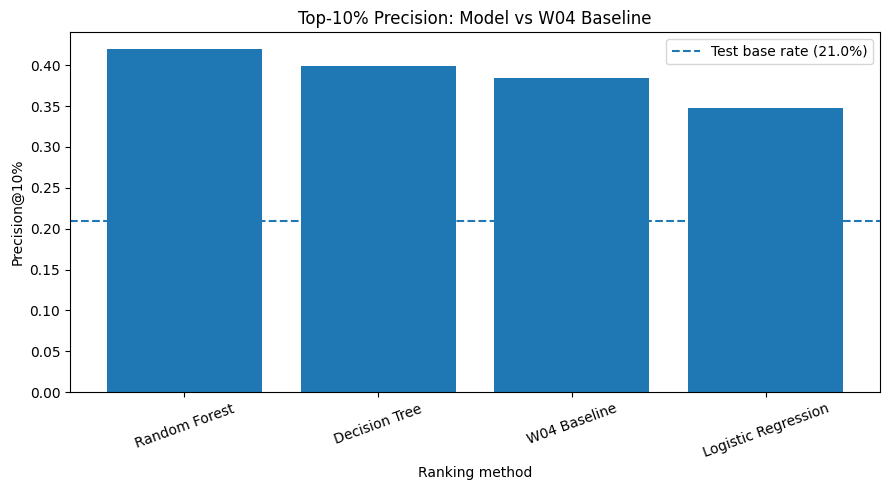

In [16]:
# Capstone — Results chart: Precision@10% comparison

import matplotlib.pyplot as plt

plot_data = ranking_results.sort_values(
    "Precision@10%",
    ascending=False
)

plt.figure(figsize=(9, 5))

plt.bar(
    plot_data["Model"],
    plot_data["Precision@10%"]
)

plt.axhline(
    base_rate,
    linestyle="--",
    label=f"Test base rate ({base_rate:.1%})"
)

plt.ylabel("Precision@10%")
plt.xlabel("Ranking method")
plt.title("Top-10% Precision: Model vs W04 Baseline")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

In [12]:
# Capstone — Limitations

limitations = [
    "The target measures whether average clicks increased from one month to the next; it does not measure whether a page actually needed a content refresh.",

    "The modeling population was restricted to rows with usable March average search position because the Week 4 baseline depends on that signal. Position availability was strongly associated with the target, so this restriction limits generalization to pages with usable Search Console position data.",

    "The evaluation is grouped by client, so the test measures generalization to clients not used for training. It does not fully reproduce every possible future deployment scenario.",

    "The Random Forest improved top-10% precision over the transparent baseline, but the improvement was modest: 41.93% versus 38.40%.",

    "The model identifies directional ranking opportunities rather than causal effects. A high score does not mean that refreshing a page will cause clicks to increase.",

    "The error analysis shows that pages with similar historical search signals can have different future outcomes, so the ranked queue should be treated as decision support rather than an automatic refresh decision."
]

for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")

1. The target measures whether average clicks increased from one month to the next; it does not measure whether a page actually needed a content refresh.
2. The modeling population was restricted to rows with usable March average search position because the Week 4 baseline depends on that signal. Position availability was strongly associated with the target, so this restriction limits generalization to pages with usable Search Console position data.
3. The evaluation is grouped by client, so the test measures generalization to clients not used for training. It does not fully reproduce every possible future deployment scenario.
4. The Random Forest improved top-10% precision over the transparent baseline, but the improvement was modest: 41.93% versus 38.40%.
5. The model identifies directional ranking opportunities rather than causal effects. A high score does not mean that refreshing a page will cause clicks to increase.
6. The error analysis shows that pages with similar historical se

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [14]:
# Capstone — Ranked recommendations and action playbook

recommendations = test_results[
    [
        "content_hash_id",
        "avg_impressions",
        "avg_clicks",
        "avg_position",
        "Random Forest"
    ]
].copy()

recommendations = recommendations.rename(
    columns={
        "Random Forest": "opportunity_score"
    }
)

# Rank by model probability
recommendations = recommendations.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = recommendations.index + 1


# ---------------------------------------------------------
# Create transparent reason codes
# ---------------------------------------------------------

impressions_q75 = model_df["avg_impressions"].quantile(0.75)
clicks_q25 = model_df["avg_clicks"].quantile(0.25)
position_q75 = model_df["avg_position"].quantile(0.75)


def reason_code(row):

    reasons = []

    if row["avg_impressions"] >= impressions_q75:
        reasons.append("high_search_visibility")

    if row["avg_clicks"] <= clicks_q25:
        reasons.append("low_historical_clicks")

    if row["avg_position"] >= position_q75:
        reasons.append("weaker_search_position")

    if not reasons:
        reasons.append("model_ranked_opportunity")

    return "; ".join(reasons)


recommendations["reason"] = recommendations.apply(
    reason_code,
    axis=1
)


# ---------------------------------------------------------
# Action playbook
# ---------------------------------------------------------

def action_from_reason(reason):

    if (
        "high_search_visibility" in reason
        and "low_historical_clicks" in reason
    ):
        return "Review title/snippet and search-result alignment"

    if "weaker_search_position" in reason:
        return "Review content relevance and search visibility"

    if "high_search_visibility" in reason:
        return "Review click capture and content alignment"

    if "low_historical_clicks" in reason:
        return "Review click-through opportunity"

    return "Review page for potential refresh"


recommendations["recommended_action"] = (
    recommendations["reason"].apply(action_from_reason)
)


# ---------------------------------------------------------
# Final editor-facing queue
# ---------------------------------------------------------

top_recommendations = recommendations.head(20)

display(
    top_recommendations[
        [
            "rank",
            "content_hash_id",
            "opportunity_score",
            "avg_impressions",
            "avg_clicks",
            "avg_position",
            "reason",
            "recommended_action"
        ]
    ].round(4)
)

,rank,content_hash_id,opportunity_score,avg_impressions,avg_clicks,avg_position,reason,recommended_action
0,1,content_bc620fb837bed015,0.8581,144.7097,0.0323,4.0621,high_search_visibility,Review click capture and content alignment
1,2,content_36c930b51b40aee4,0.8575,79.1613,0.0323,1.5791,high_search_visibility,Review click capture and content alignment
2,3,content_7558af902299e53b,0.8575,90.5806,0.0323,2.9295,high_search_visibility,Review click capture and content alignment
3,4,content_920573540c444f21,0.8574,79.2903,0.0323,2.2439,high_search_visibility,Review click capture and content alignment
4,5,content_0598730ed930bdac,0.8572,230.0645,0.0323,3.5121,high_search_visibility,Review click capture and content alignment
5,6,content_7a778532e236b263,0.8566,97.7097,0.0323,1.8645,high_search_visibility,Review click capture and content alignment
6,7,content_e361f58e2a31d1fa,0.8566,122.2258,0.0323,3.5189,high_search_visibility,Review click capture and content alignment
7,8,content_7fc1e18f7e819b5e,0.8549,188.7419,0.0323,2.4359,high_search_visibility,Review click capture and content alignment
8,9,content_f0d98d0c74f0d90d,0.8518,144.1290,0.0323,2.8558,high_search_visibility,Review click capture and content alignment
9,10,content_3a6713015bf0271c,0.8517,160.2581,0.0323,3.3787,high_search_visibility,Review click capture and content alignment


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Saved: work/outputs/capstone/ranking_results.csv
Saved: work/outputs/capstone/classification_results.csv
Saved: work/outputs/capstone/feature_importance.csv
Saved: work/outputs/capstone/top_recommendations.csv


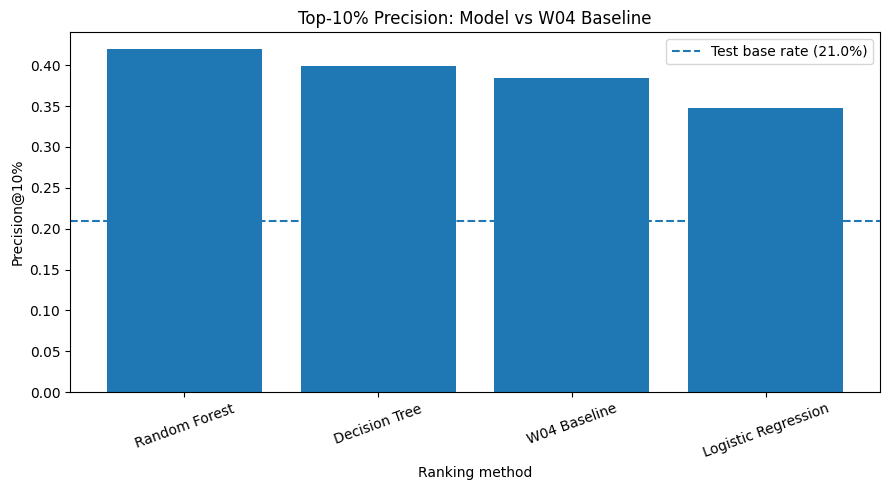

Saved: work/outputs/capstone/precision_at_10_comparison.png


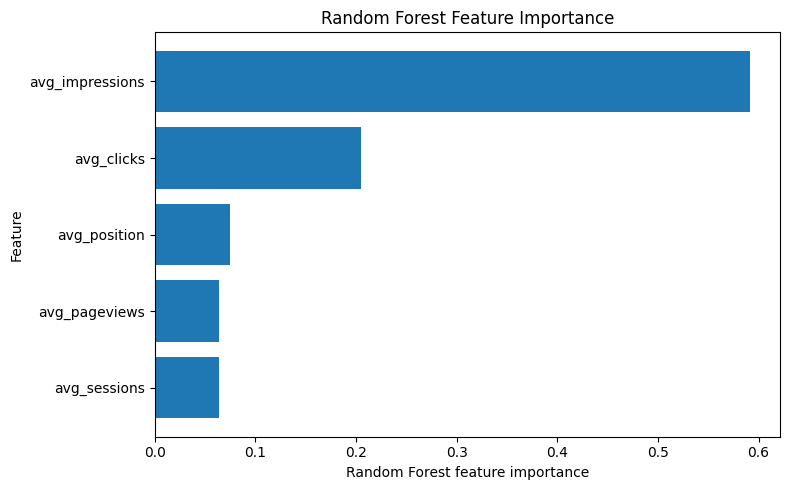

Saved: work/outputs/capstone/random_forest_feature_importance.png

Capstone paper artifacts:
- classification_results.csv
- feature_importance.csv
- precision_at_10_comparison.png
- random_forest_feature_importance.png
- ranking_results.csv
- top_recommendations.csv


In [17]:
# Capstone — Paper artifacts
# Save the main charts and tables that will be embedded in the paper.

import os
import matplotlib.pyplot as plt

# Create an output folder inside the repo
os.makedirs("work/outputs/capstone", exist_ok=True)


# ---------------------------------------------------------
# 1. Save model-vs-baseline ranking results
# ---------------------------------------------------------

ranking_results.to_csv(
    "work/outputs/capstone/ranking_results.csv",
    index=False
)

print("Saved: work/outputs/capstone/ranking_results.csv")


# ---------------------------------------------------------
# 2. Save classification results
# ---------------------------------------------------------

classification_results.to_csv(
    "work/outputs/capstone/classification_results.csv",
    index=False
)

print("Saved: work/outputs/capstone/classification_results.csv")


# ---------------------------------------------------------
# 3. Save Random Forest feature importance
# ---------------------------------------------------------

feature_importance.to_csv(
    "work/outputs/capstone/feature_importance.csv",
    index=False
)

print("Saved: work/outputs/capstone/feature_importance.csv")


# ---------------------------------------------------------
# 4. Save the top recommendation queue
# ---------------------------------------------------------

top_recommendations.to_csv(
    "work/outputs/capstone/top_recommendations.csv",
    index=False
)

print("Saved: work/outputs/capstone/top_recommendations.csv")


# ---------------------------------------------------------
# 5. Save Precision@10% chart
# ---------------------------------------------------------

plot_data = ranking_results.sort_values(
    "Precision@10%",
    ascending=False
)

plt.figure(figsize=(9, 5))

plt.bar(
    plot_data["Model"],
    plot_data["Precision@10%"]
)

plt.axhline(
    base_rate,
    linestyle="--",
    label=f"Test base rate ({base_rate:.1%})"
)

plt.ylabel("Precision@10%")
plt.xlabel("Ranking method")
plt.title("Top-10% Precision: Model vs W04 Baseline")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()

plt.savefig(
    "work/outputs/capstone/precision_at_10_comparison.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: work/outputs/capstone/precision_at_10_comparison.png"
)


# ---------------------------------------------------------
# 6. Save Random Forest feature-importance chart
# ---------------------------------------------------------

importance_plot = feature_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    importance_plot["Feature"],
    importance_plot["Importance"]
)

plt.xlabel("Random Forest feature importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()

plt.savefig(
    "work/outputs/capstone/random_forest_feature_importance.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: work/outputs/capstone/random_forest_feature_importance.png"
)


# ---------------------------------------------------------
# 7. Final artifact inventory
# ---------------------------------------------------------

print("\nCapstone paper artifacts:")

for filename in sorted(
    os.listdir("work/outputs/capstone")
):
    print("-", filename)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
